Shortest Path:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]


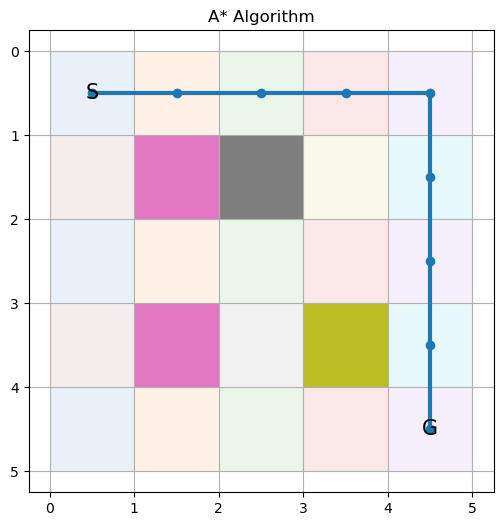

In [6]:
import heapq
import matplotlib.pyplot as plt

grid = [
    [0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0]
]

start = (0, 0)
goal = (4, 4)


# Heuristic function (Manhattan Distance)
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


# A* Algorithm
def a_star(grid, start, goal):

    rows = len(grid)
    cols = len(grid[0])

    # Priority Queue
    pq = []

    # (f, g, node, path)
    heapq.heappush(pq, (heuristic(start, goal), 0, start, [start]))

    visited = set()

    while pq:

        f, g, current, path = heapq.heappop(pq)

        if current in visited:
            continue

        visited.add(current)

        # Goal reached
        if current == goal:
            return path

        r, c = current

        # Up, Down, Left, Right
        directions = [
            (-1, 0),
            (1, 0),
            (0, -1),
            (0, 1)
        ]

        for dr, dc in directions:

            nr = r + dr
            nc = c + dc

            # Check valid position
            if (0 <= nr < rows and
                0 <= nc < cols and
                grid[nr][nc] == 0):

                neighbor = (nr, nc)

                if neighbor not in visited:

                    new_g = g + 1
                    new_f = new_g + heuristic(neighbor, goal)

                    heapq.heappush(
                        pq,
                        (new_f, new_g, neighbor, path + [neighbor])
                    )

    return None


# Find path
path = a_star(grid, start, goal)

print("Shortest Path:")
print(path)


# Draw Grid
plt.figure(figsize=(6, 6))

for r in range(len(grid)):
    for c in range(len(grid[0])):

        if grid[r][c] == 1:
            plt.fill_between(
                [c, c + 1],
                r, r + 1
            )

        else:
            plt.fill_between(
                [c, c + 1],
                r, r + 1,
                alpha=0.1
            )

# Draw path
if path:
    x = [p[1] + 0.5 for p in path]
    y = [p[0] + 0.5 for p in path]

    plt.plot(x, y, marker='o', linewidth=3)

# Start and Goal
plt.text(start[1] + 0.5, start[0] + 0.5,
         "S", ha="center", va="center", fontsize=15)

plt.text(goal[1] + 0.5, goal[0] + 0.5,
         "G", ha="center", va="center", fontsize=15)

# Grid settings
plt.xticks(range(6))
plt.yticks(range(6))
plt.grid(True)

plt.gca().invert_yaxis()

plt.title("A* Algorithm")
plt.show()